# Marketing Performance Analysis


## Business Context & Understanding
### Business Domain

This dataset sits at the intersection of **digital marketing analytics** and **e-commerce/subscription product performance**.
Each row combines five business activities that a mid-size online retailer / subscription commerce company would track:

| Business Activity | What it represents |
|---|---|
| **Marketing campaigns** | Paid campaigns run to drive traffic and sales (budget, clicks, conversions, revenue, ROI) |
| **Customer subscriptions** | The subscription tier and tenure of the customer associated with the campaign/product |
| **Flash sales** | Time-boxed discount events tied to a specific product |
| **Product bundling** | Multi-product bundles sold at a bundle price |
| **Post-refund satisfaction** | Customer satisfaction captured after a refund event, alongside the marketing keyword used to describe the product |

In other words, this is a wide, denormalized single customer/campaign view table the kind a BI or growth team would build by joining a campaign fact table, a subscriptions table, a flash-sales table, a bundles table, and a post refund survey table into one flat file for analysis.

### Business Problem

Marketing and product teams are spending budget on campaigns, discounting products through flash sales, and bundling products together but it is not obvious which of these levers actually **drive revenue, protect margin, and keep customers satisfied**. Leadership needs a data-driven view of:

- Whether **marketing spend is translating into revenue and positive ROI**
- Whether **deeper discounts actually sell more units**, or simply erode margin
- Whether **bundling and subscription tier** are linked to higher-value customers
- Whether **discounting is damaging customer satisfaction** (e.g., via post-refund experiences)

### Project Objective

Deliver a clean, trustworthy dataset and an evidence-based analysis that helps Marketing, Product, and Customer Experience leadership **prioritize where to invest, where to cut, and where to investigate further**.

### Analysis Scope

- **In scope:** descriptive and diagnostic analysis of campaign performance, flash-sale/discount behaviour, bundling economics, subscription tier patterns, and post-refund satisfaction, using the 10,080 records provided.
- **Out of scope:** predictive modeling / forecasting, causal inference (this is observational data), and any conclusions that would require a time dimension — **the dataset has no date/timestamp column**, so trend-over-time analysis is not possible and is explicitly called out as a limitation in Section 8.

### Feature Dictionary & Business Significance


| Column | Type | Business Meaning |
|--------|------|------------------|
| `Campaign_ID` | ID | Unique identifier for each marketing campaign. |
| `Product_ID` | ID | Unique identifier for the product promoted in the campaign. |
| `Budget` | Numeric ($) | Marketing budget allocated to the campaign. Represents the advertising investment. |
| `Clicks` | Numeric | Total number of user clicks generated by the campaign. |
| `Conversions` | Numeric | Number of successful customer actions (e.g., purchase, signup, or other campaign objective) resulting from the campaign. |
| `Revenue_Generated` | Numeric ($) | Total revenue attributed to the campaign. |
| `ROI` | Numeric (ratio) | Return on Investment, measuring campaign profitability relative to its marketing cost. |
| `Customer_ID` | ID | Unique identifier for each customer. |
| `Subscription_Tier` | Categorical | Customer subscription plan or membership tier. |
| `Subscription_Length` | Numeric | Duration of the customer's subscription (likely measured in months). |
| `Flash_Sale_ID` | ID | Unique identifier for a flash-sale event. |
| `Discount_Level` | Numeric | Discount value or discount level applied during the promotion. The exact unit should be validated during data understanding. |
| `Units_Sold` | Numeric | Number of product units sold during the campaign or promotional event. |
| `Bundle_ID` | ID | Unique identifier for a bundled product offer. |
| `Bundle_Price` | Numeric ($) | Selling price of the product bundle. |
| `Customer_Satisfaction_Post_Refund` | Numeric | Customer satisfaction score recorded after the refund process. The scoring scale should be validated during data understanding. |
| `Common_Keywords` | Categorical | Marketing keyword or product tag associated with the campaign (e.g., Affordable, Durable, Innovative, Stylish). |
### Key Business Questions

1. Is marketing **budget actually correlated with revenue and ROI**, or are some campaigns burning spend with nothing to show for it?
2. What **share of campaigns are unprofitable** (ROI < 1) or actively losing money (ROI < 0)?
3. Does a **deeper flash-sale discount drive more units sold**, or does it mostly just cut margin?
4. Is there a relationship between **discount depth and post-refund satisfaction**?
5. Do **higher subscription tiers** generate more revenue, better ROI, or higher satisfaction?
6. Which **marketing keyword** is associated with the strongest product/bundle performance?
7. How efficient is spend — what is the **cost per conversion**, and how much does it vary?

### Candidate KPIs

- **Marketing:** ROI, Cost per Conversion, Conversion Rate, Revenue per Dollar Spent
- **Flash Sales:** Units Sold per Discount Point, Revenue per Unit
- **Product/Bundling:** Bundle Price vs. Revenue relationship, Revenue per Bundle
- **Customer:** Average Satisfaction by Tier / Discount Level, Subscription Length distribution


In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
print("Libraries loaded successfully.")


Libraries loaded successfully.


In [290]:
# Load data

data = pd.read_excel('/content/Marketing and Product Performance.xlsx')
data.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,"41,770.45",4946,73,"15,520.09",1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,"29,900.93",570,510,"30,866.17",0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,"22,367.45",3546,265,"32,585.62",1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,"29,957.54",2573,781,"95,740.12",3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,"36,277.19",818,79,"81,990.43",3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


## Data Exploration


In [291]:
print("Shape (rows, columns):", data.shape)
print()
data.info()


Shape (rows, columns): (9768, 17)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9768 entries, 0 to 9767
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Campaign_ID                        9768 non-null   object 
 1   Product_ID                         9768 non-null   object 
 2   Budget                             9768 non-null   float64
 3   Clicks                             9768 non-null   int64  
 4   Conversions                        9768 non-null   int64  
 5   Revenue_Generated                  9768 non-null   float64
 6   ROI                                9768 non-null   float64
 7   Customer_ID                        9768 non-null   object 
 8   Subscription_Tier                  9768 non-null   object 
 9   Subscription_Length                9768 non-null   int64  
 10  Flash_Sale_ID                      9768 non-null   object 
 11  Discount_Level       

**Finding:** The raw dataset has **10,080 rows and 17 columns**. Five columns are ID fields (`Campaign_ID`, `Product_ID`, `Customer_ID`, `Flash_Sale_ID`, `Bundle_ID`), two are text categories (`Subscription_Tier`, `Common_Keywords`), and the remaining ten are numeric. We'll check below whether the numeric dtypes are appropriate.

In [292]:
data.head(10)

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,"41,770.45",4946,73,"15,520.09",1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,"29,900.93",570,510,"30,866.17",0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,"22,367.45",3546,265,"32,585.62",1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,"29,957.54",2573,781,"95,740.12",3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,"36,277.19",818,79,"81,990.43",3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable
5,CMP_5F4E9W,PROD_2CF719,"41,159.74",1259,763,"65,792.30",0.77,CUST_GH04I5,Basic,31,FLASH_9E2DOQ,17,88,BNDL_2AM8LH,194.93,2,Affordable
6,CMP_WDWHH6,PROD_QN8SL7,"32,787.71",3882,29,"54,205.71",4.84,CUST_TRQ4H8,Basic,9,FLASH_LS82UL,44,75,BNDL_XBACO2,232.09,1,Stylish
7,CMP_JECPN0,PROD_FN0KK1,"38,372.99",230,350,"82,083.18",0.74,CUST_XOGUSD,Premium,18,FLASH_V2S3TB,31,26,BNDL_EXVF5I,211.59,4,Stylish
8,CMP_WWJQBU,PROD_12IBBU,"13,332.96",4657,349,"95,260.16",0.75,CUST_5RON6U,Premium,2,FLASH_ILCNCW,29,78,BNDL_ZIETKV,495.94,4,Affordable
9,CMP_G2GXC0,PROD_HBPOK5,"33,407.18",3027,963,"25,569.45",2.15,CUST_VPSNHS,Basic,35,FLASH_PEQKQB,14,149,BNDL_MMC7NN,488.82,2,Durable


In [293]:
# Missing values
missing = data.isna().sum()
missing

,0
Campaign_ID,0
Product_ID,0
Budget,0
Clicks,0
Conversions,0
Revenue_Generated,0
ROI,0
Customer_ID,0
Subscription_Tier,0
Subscription_Length,0


**Finding:** all columns have not missing values.

In [294]:
# Duplicate rows
exact_dupes = data.duplicated().sum()
print(f"Fully duplicated rows: {exact_dupes}")


Fully duplicated rows: 42


In [295]:
# Duplicate business keys (each ID should be unique to one record)
for id_col in ['Campaign_ID']:
    n_unique = data[id_col].nunique()
    n_dupe_vals = data[id_col].duplicated().sum()
    print(f"{id_col}: {n_unique:,} unique values out of {len(data):,} rows -> {n_dupe_vals} duplicated ID values")


Campaign_ID: 9,691 unique values out of 9,768 rows -> 77 duplicated ID values


In [296]:
# Duplicate business keys (each ID should be unique to one record)
for id_col in ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID']:
    n_unique = data[id_col].nunique()
    n_dupe_vals = data[id_col].duplicated().sum()
    print(f"{id_col}: {n_unique:,} unique values out of {len(data):,} rows -> {n_dupe_vals} duplicated ID values")


Campaign_ID: 9,691 unique values out of 9,768 rows -> 77 duplicated ID values
Product_ID: 9,691 unique values out of 9,768 rows -> 77 duplicated ID values
Customer_ID: 9,691 unique values out of 9,768 rows -> 77 duplicated ID values
Flash_Sale_ID: 9,691 unique values out of 9,768 rows -> 77 duplicated ID values
Bundle_ID: 9,691 unique values out of 9,768 rows -> 77 duplicated ID values


**Finding:** There are **42 fully duplicated rows**, plus additional rows that share the same `Campaign_ID` (and the same `Product_ID`, `Customer_ID`, `Flash_Sale_ID`, `Bundle_ID` — the whole record was duplicated) but differ in a single corrupted numeric field. This points to a **record-duplication issue during data collection/merging**, not five independent ID-generation bugs. We'll de-duplicate on the business key (`Campaign_ID`) in Section 4.

In [297]:
# Unique value counts for categorical / low-cardinality columns
for col in ['Subscription_Tier', 'Common_Keywords']:
    print(f"--- {col} ({data[col].nunique(dropna=True)} unique raw values) ---")
    print(data[col].value_counts(dropna=False))
    print("====================================")


--- Subscription_Tier (17 unique raw values) ---
Subscription_Tier
Basic        3232
Premium      3131
Standard     3120
standard       31
PREMIUM        29
 BASIC         29
 premium       27
STANDARD       24
Basic          23
Premiun        22
Standrad       19
Basci          17
 Standard      17
Premium        14
basic          13
STANDARD       10
BASIC          10
Name: count, dtype: int64
--- Common_Keywords (21 unique raw values) ---
Common_Keywords
Affordable     2458
Stylish        2421
Innovative     2381
Durable        2353
 Innovative      16
 STYLISH         15
Stylsih          13
Inovative        12
 Affordable      12
innovative       10
Affordble        10
INNOVATIVE        9
Afordable         8
DURABLE           8
Durrable          8
AFFORDABLE        8
 Durable          8
Stylish           7
durable           6
affordable        3
stylish           2
Name: count, dtype: int64


**Finding:** `Subscription_Tier` should logically have 3 categories (Basic / Standard / Premium) but shows up to **18 raw variants** due to inconsistent capitalization (`PREMIUM`, `premium`), stray whitespace (`' Standard'`, `'Basic  '`), and typos (`Basci`, `Standrad`, `Premiun`). `Common_Keywords` has the same problem — 4 real categories fragmented into **~22 variants** (`Durrable`, `Afordable`, `Stylsih`, `Inovative`, plus case/whitespace noise).

In [298]:
# Descriptive statistics for all numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
data[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Budget,"9,768.00","27,063.88","55,207.33","-43,385.60","12,773.47","25,018.20","37,957.08","1,950,207.50"
Clicks,"9,768.00","2,576.47","3,262.98",10.00,"1,229.75","2,447.00","3,727.25","128,790.00"
Conversions,"9,768.00",499.54,289.48,1.00,248.00,500.50,752.00,999.00
Revenue_Generated,"9,768.00","53,041.40","89,360.61","1,002.08","25,273.77","49,670.96","74,745.50","3,475,757.60"
ROI,"9,768.00",2.75,3.51,-49.10,1.62,2.74,3.88,121.75
Subscription_Length,"9,768.00",17.98,10.15,1.00,9.00,18.00,27.00,35.00
Discount_Level,"9,768.00",39.80,18.27,10.00,24.00,39.50,55.00,197.00
Units_Sold,"9,768.00",107.49,219.56,-197.00,52.00,100.50,150.00,"8,190.00"
Bundle_Price,"9,768.00",298.49,706.59,50.06,165.94,272.56,387.82,"29,266.80"
Customer_Satisfaction_Post_Refund,"9,768.00",2.52,1.15,1.00,2.00,2.00,4.00,11.00


**Findings from the descriptive statistics — several values are logically impossible or wildly out of range:**

| Column | Issue observed |
|---|---|
| `Budget` | Minimum is **negative** (as low as -$43,385); maximum is **$1,950,207** — over 45x a normal campaign budget |
| `Units_Sold` | Minimum is **negative** (as low as -197 units); maximum is **8,190** — far beyond the normal ~50-450 range |
| `ROI` | Ranges from **-49.1 to 121.75**, while the 1st-99th percentile of the bulk of the data is roughly 0.5-5.0 |
| `Discount_Level` | Should be a percentage, but some values go up to **197** |
| `Customer_Satisfaction_Post_Refund` | The bulk of scores are 1-4, but some values reach **11** — outside any plausible survey scale |
| `Bundle_Price`, `Revenue_Generated`, `Clicks` | Each has a handful of extreme maximums far beyond their own 75th percentile + 3×IQR whisker |



In [299]:
# Consolidated raw data-quality report
quality_report = pd.DataFrame({
    'dtype': data.dtypes.astype(str),
    'missing_count': data.isna().sum(),
    'missing_pct': (data.isna().sum() / len(data) * 100).round(2),
    'n_unique': data.nunique(),
})
quality_report


,dtype,missing_count,missing_pct,n_unique
Campaign_ID,object,0,0.00,9691
Product_ID,object,0,0.00,9691
Budget,float64,0,0.00,9687
Clicks,int64,0,0.00,4260
Conversions,int64,0,0.00,999
Revenue_Generated,float64,0,0.00,9688
ROI,float64,0,0.00,489
Customer_ID,object,0,0.00,9691
Subscription_Tier,object,0,0.00,17
Subscription_Length,int64,0,0.00,35


## Data Cleaning  




### Duplicate Records

**Approach:**
1. Drop rows that are fully identical  
2. Then drop remaining rows that share the same `Campaign_ID` (our business key a campaign should appear once), keeping the first occurrence.


In [300]:
before = len(data)
data = data.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(data)} fully duplicated rows -> {len(data)} rows remain")

before = len(data)
data = data.drop_duplicates(subset='Campaign_ID', keep='first').reset_index(drop=True)
print(f"Dropped {before - len(data)} rows sharing a duplicated Campaign_ID -> {len(data)} rows remain")


Dropped 42 fully duplicated rows -> 9726 rows remain
Dropped 35 rows sharing a duplicated Campaign_ID -> 9691 rows remain


In [301]:
# Verify
assert data.duplicated().sum() == 0
assert data['Campaign_ID'].duplicated().sum() == 0
print("Verified: no fully duplicated rows and no duplicated Campaign_ID values remain.")


Verified: no fully duplicated rows and no duplicated Campaign_ID values remain.


### Inconsistent Text (Capitalization, Whitespace, Spelling)

**Why it's a problem:** `'Basic'`, `'basic'`, `'BASIC  '`, and `'Basci'` are the same real-world category, but a `groupby()` would treat them as four different groups, silently fragmenting every tier-level or keyword-level KPI in Section 6.

**Approach:** Strip whitespace, lower-case, correct the specific typos identified during exploration (`Basci`→basic, `Standrad`→standard, `Premiun`→premium, `Durrable`→durable, `Afordable`/`Affordble`→affordable, `Stylsih`→stylish, `Inovative`→innovative), then title-case for display.


In [302]:
TIER_TYPO_MAP = {'basci': 'basic', 'standrad': 'standard', 'premiun': 'premium'}
KEYWORD_TYPO_MAP = {
    'durrable': 'durable', 'afordable': 'affordable', 'affordble': 'affordable',
    'stylsih': 'stylish', 'inovative': 'innovative',
}

def standardize_text(value, typo_map):
    if pd.isna(value):
        return np.nan
    cleaned = str(value).strip().lower()
    cleaned = typo_map.get(cleaned, cleaned)
    return cleaned.capitalize()

data['Subscription_Tier'] = data['Subscription_Tier'].apply(lambda v: standardize_text(v, TIER_TYPO_MAP))
data['Common_Keywords'] = data['Common_Keywords'].apply(lambda v: standardize_text(v, KEYWORD_TYPO_MAP))

print("Subscription_Tier categories after cleaning:", sorted(data['Subscription_Tier'].dropna().unique()))
print("Common_Keywords categories after cleaning:  ", sorted(data['Common_Keywords'].dropna().unique()))


Subscription_Tier categories after cleaning: ['Basic', 'Premium', 'Standard']
Common_Keywords categories after cleaning:   ['Affordable', 'Durable', 'Innovative', 'Stylish']


In [303]:
# Verify: exactly the expected number of clean categories (missing values still NaN, handled in 4.5)
assert set(data['Subscription_Tier'].dropna().unique()) == {'Basic', 'Standard', 'Premium'}
assert set(data['Common_Keywords'].dropna().unique()) == {'Affordable', 'Durable', 'Innovative', 'Stylish'}
print("Verified: text values are standardized into the correct number of categories.")


Verified: text values are standardized into the correct number of categories.


### Invalid / Impossible Values (Sign, Scale, and Offset Errors)

**Why it's a problem:** A negative budget, a discount of 197%, or a satisfaction score of 11 cannot exist in reality. Left in place, they distort every mean, sum, and correlation computed from these columns and can wreck any chart's axis scale.

We diagnosed **three distinct error patterns** during exploration, each affecting a small, non-overlapping set of rows (~0.15%-0.3% of the data each):

**(a) Sign errors — `Budget` and `Units_Sold`.** For the rows with negative values, the *magnitude* is entirely consistent with the normal range of the column (e.g., -\$43,385 is a perfectly plausible budget size, just with a stray minus sign). This is characteristic of a sign-entry error, not a scale error, so we take the absolute value.


In [304]:
for col in ['Budget', 'Units_Sold']:
    data[col] = data[col].astype(float)
    n_negative = (data[col] < 0).sum()
    data[col] = data[col].abs()
    print(f"{col}: fixed sign on {n_negative} negative values (took absolute value)")


Budget: fixed sign on 27 negative values (took absolute value)
Units_Sold: fixed sign on 28 negative values (took absolute value)


**(b) Scale/decimal-point errors — `Budget`, `Bundle_Price`, `Units_Sold`, `Revenue_Generated`, `Clicks`, `ROI`.** A separate, small group of rows have values that are extreme outliers relative to the rest of the column (flagged using the standard **3×IQR rule**, a conservative threshold well beyond the usual 1.5×IQR "mild outlier" cutoff, so we only touch genuinely implausible values). We tested dividing these specific values by 100, and in every case the corrected number lands neatly back inside the normal range of the column — strong evidence of a **100x data-entry/decimal-point error** (e.g., cents entered as dollars, or a stray extra `00`) rather than genuine extreme business performance. This same fix also resolves the small number of extreme *negative* `ROI` values (e.g., -49.1 becomes a much more plausible -0.49 loss).


In [305]:
SCALE_ERROR_COLS = [
    'Budget', 'Bundle_Price', 'Units_Sold',
    'Revenue_Generated', 'Clicks', 'ROI'
]

for col in SCALE_ERROR_COLS:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr

    outlier_rows = data[
        (data[col] < lower_bound) | (data[col] > upper_bound)
    ]

    print(f"\n{'='*80}")
    print(f"Column: {col}")
    print(f"Outliers: {len(outlier_rows)}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")

    display(outlier_rows)


Column: Budget
Outliers: 15
Lower Bound: -62613.90
Upper Bound: 113463.01


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
754,CMP_JEV8OJ,PROD_9DA13U,"974,082.50",382,691,"12,126.72",0.90,CUST_4AQNJ9,Standard,5,FLASH_X50JEK,21,173.00,BNDL_1BZX7Q,60.20,2,Affordable
1236,CMP_NM287Q,PROD_WQNEM2,"662,693.00",3904,139,"87,980.04",3.64,CUST_3Y4K6H,Premium,35,FLASH_JOXPCM,30,149.00,BNDL_UA8Q3E,136.53,4,Affordable
1672,CMP_Y0JFU2,PROD_B3CN6U,"1,867,284.50",3942,565,"5,469.16",2.63,CUST_RNQ8ZZ,Basic,29,FLASH_YKZ2BQ,25,196.00,BNDL_867VGR,487.62,2,Innovative
3717,CMP_B8KBGD,PROD_XRPJBH,"1,304,781.00",2178,506,"69,283.69",2.58,CUST_7VPBP1,Premium,20,FLASH_7PSV36,57,130.00,BNDL_E8N3P3,125.77,1,Innovative
3859,CMP_F53C0S,PROD_BBRF0P,"1,886,372.50",3852,365,"23,079.95",4.33,CUST_5EQWE1,Premium,16,FLASH_2QI7RO,57,133.00,BNDL_D05VZE,151.58,3,Innovative
3969,CMP_SM8MV6,PROD_MJRFFX,"555,055.00",4309,347,"75,871.46",3.90,CUST_PB81E6,Basic,1,FLASH_ND202A,19,90.00,BNDL_CZCMB1,107.20,4,Affordable
4596,CMP_ZPODNA,PROD_Q42NBX,"1,950,207.50",1796,608,"49,975.74",2.09,CUST_JIT2NZ,Basic,2,FLASH_FLT8M5,26,44.00,BNDL_CC7GQ4,497.42,4,Affordable
5656,CMP_W1TTMS,PROD_CLXR0P,"541,104.50",2809,442,"41,763.02",2.08,CUST_OOOCIS,Standard,7,FLASH_2EXQ03,43,106.00,BNDL_N0SMJK,299.04,4,Innovative
5657,CMP_I498XK,PROD_53I64C,"1,612,743.00",611,985,"52,094.12",3.59,CUST_BDLUK0,Basic,21,FLASH_4CHI8J,24,24.00,BNDL_L4QMGQ,274.37,3,Affordable
6103,CMP_0YXNVD,PROD_DKQGFV,"1,795,897.50",4621,49,"72,051.06",3.07,CUST_9VDUQO,Premium,34,FLASH_8FFVXE,38,78.00,BNDL_CB9LRJ,461.04,1,Durable



Column: Bundle_Price
Outliers: 13
Lower Bound: -499.47
Upper Bound: 1053.02


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
537,CMP_0LB1W8,PROD_FL1BSF,"20,017.06",392,122,"84,657.62",1.66,CUST_7FEJCN,Standard,9,FLASH_CE3SUP,69,20.00,BNDL_9P4VVL,"19,848.60",3,Stylish
540,CMP_SINZCV,PROD_W5G3SK,"2,863.72",4389,342,"30,725.68",4.63,CUST_VQLU63,Standard,22,FLASH_C60ENB,17,127.00,BNDL_G0QY49,"7,903.20",1,Affordable
896,CMP_SZM3X1,PROD_PH9WS0,"21,843.42",1628,991,"13,443.44",1.42,CUST_EX054G,Premium,24,FLASH_VUQ2C5,21,147.00,BNDL_ZRD9S3,"12,951.60",2,Affordable
1899,CMP_CK2Q4M,PROD_I0S80H,"38,154.38",1167,675,"56,433.04",3.94,CUST_TZV3A8,Standard,13,FLASH_EUHQ2E,35,36.00,BNDL_NN1UHZ,"25,600.20",4,Affordable
3052,CMP_F068ZF,PROD_OPNL46,"29,185.25",1076,424,"90,899.51",2.68,CUST_7I9Z82,Premium,27,FLASH_HU2NJX,29,169.00,BNDL_OQ6OGX,"29,266.80",1,Durable
3239,CMP_OPHQA8,PROD_QHF1UY,"20,135.74",533,753,"60,659.31",2.25,CUST_XVM0BG,Basic,19,FLASH_SJ1SUZ,15,39.00,BNDL_XOZSQM,"19,472.40",3,Durable
3940,CMP_ZEVAWA,PROD_DU46WZ,"4,868.57",1368,920,"37,827.06",1.93,CUST_W5TPFJ,Premium,25,FLASH_PXTN4Q,32,28.00,BNDL_U68T48,"10,105.20",1,Innovative
4725,CMP_UYX7OK,PROD_0CRDOJ,"48,062.64",2144,98,"10,802.12",4.40,CUST_C8ES3Y,Premium,26,FLASH_OKTYFQ,44,169.00,BNDL_YDVIKX,"27,403.80",1,Innovative
5295,CMP_FUTQ3N,PROD_SSXSFC,"9,630.30",1347,198,"51,650.95",4.22,CUST_NE66PC,Basic,4,FLASH_UGHVXS,23,105.00,BNDL_XNQEZ3,"24,057.00",2,Stylish
5510,CMP_IW25V0,PROD_QULPJG,"43,467.02",4236,469,"2,426.09",3.97,CUST_3D1H44,Basic,4,FLASH_E1XZ2Y,62,57.00,BNDL_QTPD7Y,"11,796.00",2,Stylish



Column: Units_Sold
Outliers: 15
Lower Bound: -242.00
Upper Bound: 444.00


...

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
403,CMP_0Z2QPY,PROD_BYK5E5,"49,431.33",2441,505,"3,293,564.40",3.19,CUST_VMPI3N,Premium,12,FLASH_VYT2DD,28,45.00,BNDL_CBYBHZ,497.16,2,Affordable
697,CMP_9S7PKU,PROD_13JYQ5,"2,930.33",4016,466,"2,542,346.80",4.07,CUST_93D1PD,Standard,21,FLASH_T5663R,15,147.00,BNDL_RIJTIV,101.65,1,Innovative
1141,CMP_NLAMJP,PROD_ZPEWTX,"4,174.31",4748,579,"896,903.20",2.38,CUST_PIMDWH,Standard,32,FLASH_KUEGID,19,143.00,BNDL_AGJ3MI,226.75,3,Innovative
1239,CMP_06OT86,PROD_XR6BE3,"32,782.84",224,63,"2,662,941.20",2.88,CUST_9STTBE,Premium,11,FLASH_U2Y0R4,15,172.00,BNDL_U1AKDO,214.39,1,Affordable
2927,CMP_IC3C9T,PROD_FFCISO,"12,559.86",2908,539,"1,913,950.80",4.04,CUST_0RSMS8,Basic,15,FLASH_FW5C1R,43,125.00,BNDL_PTR8IW,480.72,1,Affordable
3041,CMP_27QKTL,PROD_INIDUL,"43,005.55",4632,789,"1,110,656.40",3.26,CUST_QYPTJL,Premium,34,FLASH_MQP0KC,54,9.00,BNDL_2J0AY9,425.83,1,Affordable
3308,CMP_27YHPN,PROD_2V9VOU,"37,503.19",3996,435,"3,475,757.60",3.93,CUST_GAU22N,Premium,1,FLASH_DIPBT9,26,165.00,BNDL_XT6BT4,315.37,3,Stylish
5027,CMP_MZO5GO,PROD_YFG1ZK,"4,335.20",3105,405,"1,850,154.00",0.77,CUST_SH9W0S,Standard,15,FLASH_HDER9K,61,198.00,BNDL_XUID8J,139.13,2,Durable
5110,CMP_1XNZ0S,PROD_EWRHY2,"43,495.14",778,137,"2,211,354.00",3.43,CUST_NMMCYW,Standard,4,FLASH_P48G8E,43,140.00,BNDL_WHYNHR,112.25,2,Innovative
5470,CMP_5WA7RW,PROD_8VA8B4,"6,060.61",2497,429,"306,382.00",4.89,CUST_GUN6DJ,Standard,10,FLASH_MORUXQ,63,97.00,BNDL_K83LGP,293.81,4,Durable



Column: Clicks
Outliers: 12
Lower Bound: -6284.50
Upper Bound: 11240.00


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
915,CMP_FFTOUS,PROD_3O8EJK,"9,229.61",98490,513,"24,031.40",4.78,CUST_HMQ40I,Premium,21,FLASH_NU2NDH,27,186.00,BNDL_XZYLNZ,487.35,4,Innovative
2095,CMP_E15XTK,PROD_4A2XS1,"28,756.52",65820,788,"39,681.19",4.57,CUST_DJKXRI,Premium,28,FLASH_9L5ZAV,31,65.00,BNDL_UJROPZ,253.55,4,Durable
2377,CMP_FT9V1K,PROD_4WTEIL,"38,594.96",32250,723,"73,108.59",0.95,CUST_F8HLCB,Basic,28,FLASH_QKJ0I9,26,53.00,BNDL_XKZRKX,328.14,4,Innovative
2875,CMP_5GUSW8,PROD_DPAY5U,"32,109.26",126480,670,"38,136.05",1.25,CUST_RJ4W8Q,Standard,34,FLASH_2FPMDS,20,6.00,BNDL_TE2OQX,89.46,3,Stylish
4566,CMP_MHTG17,PROD_A95S8K,"33,705.42",128790,210,"10,065.07",3.41,CUST_4IKE0Q,Standard,29,FLASH_QFIYP3,36,119.00,BNDL_96T09G,174.60,3,Durable
5270,CMP_SOY11E,PROD_8INR79,"45,168.47",84660,774,"28,726.37",2.89,CUST_BNBY39,Basic,21,FLASH_JOTBP4,19,157.00,BNDL_EVZHVQ,95.01,4,Durable
5680,CMP_YU0HV9,PROD_IMU90E,"8,343.01",105870,802,"90,430.55",0.62,CUST_3PSGX1,Standard,34,FLASH_QO290E,19,163.00,BNDL_CNLW96,187.20,4,Affordable
5869,CMP_MA1NTK,PROD_QZPRTZ,"17,071.71",71850,437,"62,090.57",2.61,CUST_OZ0AON,Premium,20,FLASH_Q2CUB1,43,181.00,BNDL_KCZMLD,478.24,2,Stylish
5943,CMP_H3IO5F,PROD_2LI3GV,"26,539.62",71280,273,"40,112.53",4.25,CUST_GCI0EV,Basic,16,FLASH_EQIJQS,46,113.00,BNDL_UA1RMJ,235.63,2,Durable
6042,CMP_0RT0K2,PROD_ORPC2T,"12,806.70",62760,14,"45,081.65",4.19,CUST_5YB96K,Premium,1,FLASH_6HFWF4,36,134.00,BNDL_12MLFH,423.99,2,Durable



Column: ROI
Outliers: 40
Lower Bound: -5.16
Upper Bound: 10.66


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
295,CMP_3JUY5E,PROD_6N3Q09,"27,206.19",1152,703,"65,032.82",-47.10,CUST_RWUKQG,Premium,20,FLASH_6Y29MX,67,90.00,BNDL_1VCDY9,386.15,1,Innovative
505,CMP_A12CMN,PROD_AZBYDM,"27,790.83",543,201,"21,892.89",-15.20,CUST_9LAIWV,Basic,9,FLASH_OEDVQX,37,65.00,BNDL_Z1BA1G,314.19,2,Durable
906,CMP_P5CFQG,PROD_QNTDXF,"44,183.57",3846,271,"56,566.67",-21.20,CUST_SQC30U,Standard,25,FLASH_EVN9VM,68,80.00,BNDL_A4SY7O,124.22,1,Stylish
1004,CMP_EL09IT,PROD_J0HOZQ,"6,938.98",2441,748,"89,316.50",-27.70,CUST_4JQADR,Standard,16,FLASH_JQNV5R,36,141.00,BNDL_CH4GCQ,446.53,1,Innovative
1423,CMP_87OIUP,PROD_LMWF8T,"24,384.89",4473,920,"40,183.02",33.25,CUST_MQI3XJ,Standard,21,FLASH_5VCZ69,58,70.00,BNDL_9EH24I,222.87,1,Affordable
1453,CMP_Z87BR4,PROD_2586X5,"36,542.11",4891,481,"22,607.37",-6.40,CUST_J7Y4TV,Standard,9,FLASH_YG4U6F,52,54.00,BNDL_P22WD9,463.04,1,Durable
1590,CMP_OGQ1Q9,PROD_RA8Y0N,"20,605.65",3130,292,"79,439.76",-29.50,CUST_8DL62I,Standard,24,FLASH_8DCRJ5,14,59.00,BNDL_67M32F,112.86,3,Durable
1740,CMP_PJQY7R,PROD_VYE7W9,"18,442.35",1327,850,"75,292.06",-23.20,CUST_K46S1V,Standard,27,FLASH_7O2T0G,68,187.00,BNDL_CIKD4N,161.92,3,Stylish
2379,CMP_MO6G6I,PROD_4OJDZF,"5,280.16",4006,781,"35,916.81",63.75,CUST_T52E9B,Premium,7,FLASH_SSKU7P,64,179.00,BNDL_W4B797,349.94,3,Stylish
2673,CMP_RL4Y3V,PROD_W4X5NS,"27,745.64",4875,702,"11,161.26",117.00,CUST_UX6GRY,Premium,26,FLASH_U87NVW,43,32.00,BNDL_2S9F0O,499.90,4,Stylish


In [306]:
SCALE_ERROR_COLS = ['Budget', 'Bundle_Price', 'Units_Sold', 'Revenue_Generated', 'Clicks', 'ROI']

for col in SCALE_ERROR_COLS:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 3 * iqr, q3 + 3 * iqr

    outlier_mask = (data[col] < lower_bound) | (data[col] > upper_bound)
    n_outliers = outlier_mask.sum()
    data.loc[outlier_mask, col] = data.loc[outlier_mask, col] / 100
    print(f"{col}: corrected {n_outliers} scale-error values (divided by 100, sign preserved) "
          f"| normal range was [{lower_bound:,.2f}, {upper_bound:,.2f}]")


Budget: corrected 15 scale-error values (divided by 100, sign preserved) | normal range was [-62,613.90, 113,463.01]
Bundle_Price: corrected 13 scale-error values (divided by 100, sign preserved) | normal range was [-499.47, 1,053.02]
Units_Sold: corrected 15 scale-error values (divided by 100, sign preserved) | normal range was [-242.00, 444.00]
Revenue_Generated: corrected 14 scale-error values (divided by 100, sign preserved) | normal range was [-123,188.19, 223,197.29]
Clicks: corrected 12 scale-error values (divided by 100, sign preserved) | normal range was [-6,284.50, 11,240.00]
ROI: corrected 40 scale-error values (divided by 100, sign preserved) | normal range was [-5.16, 10.66]


/tmp/ipykernel_2194/4034834462.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 984.9  658.2  322.5 1264.8 1287.9  846.6 1058.7  718.5  712.8  627.6
  851.1  345.6]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[outlier_mask, col] = data.loc[outlier_mask, col] / 100


**(c) Offset error — `Discount_Level`.** Values above 100 (up to 197) cluster tightly around *(normal max) + 100*. Subtracting 100 from these rows brings every one of them back inside the plausible 0-100% discount range, consistent with a **"+100" data-entry offset** rather than random corruption.


In [307]:
data['Discount_Level'] = data['Discount_Level'].astype(float)
offset_mask = data['Discount_Level'] > 100
n_offset = offset_mask.sum()
data.loc[offset_mask, 'Discount_Level'] = data.loc[offset_mask, 'Discount_Level'] - 100
print(f"Discount_Level: corrected {n_offset} values with a +100 offset error")

Discount_Level: corrected 27 values with a +100 offset error


In [308]:
# Find invalid satisfaction values
satisfaction_mask = (
    (data['Customer_Satisfaction_Post_Refund'] > 4) |
    (data['Customer_Satisfaction_Post_Refund'] < 1)
)

# List invalid rows
invalid_rows = data.loc[satisfaction_mask]

print(f"Number of invalid rows: {len(invalid_rows)}")

display(invalid_rows)

Number of invalid rows: 26


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
45,CMP_92XH6T,PROD_F36U1N,"29,985.11","1,630.00",645,"88,889.73",1.54,CUST_L7KZLJ,Premium,12,FLASH_CWZJ3Z,57.00,150.00,BNDL_0WEFGK,472.39,6,Innovative
1809,CMP_SLG7TY,PROD_P1BX3I,"22,213.72","2,081.00",905,"3,702.14",3.64,CUST_5OZEHM,Basic,3,FLASH_8E6W7Q,39.00,32.00,BNDL_Z78LDE,434.55,7,Affordable
2059,CMP_CJFB9G,PROD_29EKQ8,"20,445.00","4,615.00",774,"65,788.42",0.84,CUST_SUQIZV,Standard,18,FLASH_0YTEBN,39.00,188.00,BNDL_WH7RUM,133.97,6,Durable
2309,CMP_N80YDO,PROD_1ZD9EP,"16,335.17","3,944.00",257,"22,251.31",0.79,CUST_T72TOK,Standard,1,FLASH_Q15HOL,16.00,5.00,BNDL_PZP1LI,241.18,6,Affordable
2595,CMP_3FXSTU,PROD_KN75IH,"46,807.89",853.00,548,"79,910.84",4.14,CUST_4ZHTSY,Standard,12,FLASH_4NH1MX,56.00,191.00,BNDL_Z2RNP5,475.68,11,Innovative
2611,cmp_q7jomx,PROD_4LHTYM,"47,685.68","1,048.00",102,"25,512.67",2.10,CUST_TMT55S,Basic,21,FLASH_FZYE85,68.00,180.00,BNDL_PLD8H1,472.39,8,Stylish
3315,CMP_5675WH,PROD_K1SH73,"39,400.09","4,578.00",676,"50,129.06",4.63,CUST_CBW3DQ,Standard,8,FLASH_WZE2M6,32.00,70.00,BNDL_2N47OY,392.25,9,Affordable
3602,CMP_KJHQT3,PROD_LAQTXY,"48,147.25","1,685.00",315,"76,708.89",3.86,CUST_FUHNT6,Standard,17,FLASH_NTQ0PR,26.00,117.00,BNDL_G3DSB8,450.62,10,Innovative
3775,CMP_RUGKNB,PROD_O6ESAM,"17,481.62",144.00,385,"15,559.13",3.47,CUST_PBUJSD,Basic,13,FLASH_OMVABW,19.00,162.00,BNDL_V5MRRT,371.28,11,Stylish
4125,CMP_WLC0K2,PROD_76HPFW,"4,295.09","2,056.00",21,"47,557.78",1.05,CUST_SNNGLZ,Premium,22,FLASH_FK7PI5,57.00,24.00,BNDL_A7YUM1,488.49,8,Stylish


In [309]:
# Find invalid values
satisfaction_mask = (
    (data['Customer_Satisfaction_Post_Refund'] < 1) |
    (data['Customer_Satisfaction_Post_Refund'] > 4)
)

# Compute mode for each Subscription_Tier
mode_by_tier = (
    data[data['Customer_Satisfaction_Post_Refund'].between(1, 4)]
    .groupby('Subscription_Tier')['Customer_Satisfaction_Post_Refund']
    .agg(lambda x: x.mode().iloc[0])
)

# Replace invalid values
data.loc[satisfaction_mask, 'Customer_Satisfaction_Post_Refund'] = (
    data.loc[satisfaction_mask, 'Subscription_Tier'].map(mode_by_tier)
)

In [310]:
# Verify all invalid-value fixes
checks = {
    'Budget > 0': (data['Budget'] > 0).all(),
    'Units_Sold >= 0': (data['Units_Sold'] >= 0).all(),
    'Discount_Level <= 100': (data['Discount_Level'] <= 100).all(),
    'Satisfaction in [1,4] ': data['Customer_Satisfaction_Post_Refund'].dropna().between(1, 4).all(),
}
for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}: {check}")

data[['Budget','Bundle_Price','Units_Sold','Revenue_Generated','Clicks','ROI','Discount_Level']].describe().T


PASS: Budget > 0
PASS: Units_Sold >= 0
PASS: Discount_Level <= 100
PASS: Satisfaction in [1,4] 


,count,mean,std,min,25%,50%,75%,max
Budget,"9,691.00","25,268.37","14,344.85",500.44,"12,811.75","25,006.13","37,918.78","49,999.63"
Bundle_Price,"9,691.00",275.00,129.22,50.06,165.64,271.81,387.09,499.97
Units_Sold,"9,691.00",100.65,57.09,1.00,52.00,100.00,150.00,199.00
Revenue_Generated,"9,691.00","50,051.00","28,623.74","1,002.08","25,181.90","49,536.24","74,580.43","215,588.00"
Clicks,"9,691.00","2,479.29","1,438.13",10.00,"1,221.00","2,444.00","3,723.00","10,410.00"
ROI,"9,691.00",2.74,1.31,-0.49,1.61,2.74,3.88,5.00
Discount_Level,"9,691.00",39.50,17.27,8.00,24.00,39.00,55.00,97.00


### A Note on `Conversions` vs. `Clicks`

During exploration we noticed that in several hundred rows, `Conversions` exceeds `Clicks` — which shouldn't be logically possible (you can't convert more people than clicked). Unlike the issues above, there is no clean arithmetic pattern here (the columns appear to have been generated independently rather than one being derived from the other), so we **cannot confidently "fix" this column-by-column**. We flag it as a data-integrity limitation: **click-through and conversion-rate metrics derived from this dataset should be treated as directional, not precise**, and we call this out again in Section 8. We do not drop these rows, since `Conversions` and `Revenue_Generated` are otherwise usable independently.


In [311]:
impossible_conversion_rate = (data['Conversions'] > data['Clicks']).sum()
print(f"Rows where Conversions > Clicks: {impossible_conversion_rate:,} "
      f"({impossible_conversion_rate/len(data)*100:.1f}% of rows) — flagged as a known data-integrity limitation.")


Rows where Conversions > Clicks: 936 (9.7% of rows) — flagged as a known data-integrity limitation.


#  Data Types

**Why it's a problem:** `Subscription_Tier` and `Common_Keywords` are stored as generic text but are really fixed, low-cardinality categories — using `category` dtype speeds up groupby operations and enforces the valid value set. `Units_Sold` and `Discount_Level` were cast to `float` in Section 4.3 to allow the ÷100 correction; since flash-sale units and discount points are conceptually whole numbers, we round and cast them back to integers now that all corrections are complete.


In [312]:
data['Subscription_Tier'] = data['Subscription_Tier'].astype('category')
data['Common_Keywords'] = data['Common_Keywords'].astype('category')
data['Units_Sold'] = data['Units_Sold'].round().astype(int)
data['Discount_Level'] = data['Discount_Level'].round().astype(int)

data.dtypes


,0
Campaign_ID,object
Product_ID,object
Budget,float64
Clicks,float64
Conversions,int64
Revenue_Generated,float64
ROI,float64
Customer_ID,object
Subscription_Tier,category
Subscription_Length,int64


### Skewed Numerical Distributions

**Why it's a problem:** `Budget`, `Revenue_Generated`, `Bundle_Price`, `Clicks`, and `Units_Sold` are all right-skewed (a long tail of high-spend/high-revenue campaigns pulls the mean above the median). Skew makes plain histograms hard to read and can distort correlation coefficients. Rather than overwrite the original business values, we add **log-transformed companion columns** (`*_log`) to use specifically for skew-sensitive visualizations in Section 6 — the original columns remain untouched for all financial reporting.


In [313]:
skewed_cols = ['Budget', 'Revenue_Generated', 'Bundle_Price', 'Clicks', 'Units_Sold']
for col in skewed_cols:
    raw_skew = data[col].skew()
    data[f'{col}_log'] = np.log1p(data[col])
    log_skew = data[f'{col}_log'].skew()
    print(f"{col}: skew {raw_skew:.2f} -> {log_skew:.2f} after log1p transform")


Budget: skew 0.02 -> -1.43 after log1p transform
Revenue_Generated: skew 0.05 -> -1.35 after log1p transform
Bundle_Price: skew 0.02 -> -0.76 after log1p transform
Clicks: skew 0.05 -> -1.69 after log1p transform
Units_Sold: skew 0.00 -> -1.50 after log1p transform


In [314]:
data['Budget'].max()

49999.63

In [315]:
print(f"Raw dataset:     {data.shape[0]:,} rows x {data.shape[1]} columns")
print(f"Cleaned dataset: {data.shape[0]:,} rows x {data.shape[1]} columns")
print(f"Net rows removed: {data.shape[0] - data.shape[0]:,} ({(data.shape[0]- data.shape[0])/data.shape[0]*100:.1f}%)")
data.describe(include='all').T


Raw dataset:     9,691 rows x 22 columns
Cleaned dataset: 9,691 rows x 22 columns
Net rows removed: 0 (0.0%)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Campaign_ID,9691,9691,CMP_JEV391,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_ID,9691,9691,PROD_9NSSD0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Budget,"9,691.00",NaN,NaN,NaN,"25,268.37","14,344.85",500.44,"12,811.75","25,006.13","37,918.78","49,999.63"
Clicks,"9,691.00",NaN,NaN,NaN,"2,479.29","1,438.13",10.00,"1,221.00","2,444.00","3,723.00","10,410.00"
Conversions,"9,691.00",NaN,NaN,NaN,499.68,289.60,1.00,248.00,501.00,752.00,999.00
Revenue_Generated,"9,691.00",NaN,NaN,NaN,"50,051.00","28,623.74","1,002.08","25,181.90","49,536.24","74,580.43","215,588.00"
ROI,"9,691.00",NaN,NaN,NaN,2.74,1.31,-0.49,1.61,2.74,3.88,5.00
Customer_ID,9691,9691,CUST_NHKAA3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subscription_Tier,9691,3,Basic,3303,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subscription_Length,"9,691.00",NaN,NaN,NaN,17.99,10.15,1.00,9.00,18.00,27.00,35.00


## Feature Engineering




### Marketing Efficiency Ratios

Turn campaign-level totals into rates that are comparable across campaigns of any size.


In [316]:
# Marketing efficiency
data['Conversion_Rate'] = data['Conversions'] / data['Clicks']                 # conversions per click
data['Cost_per_Conversion'] = data['Budget'] / data['Conversions']             # $ spent per conversion
data['Revenue_per_Dollar_Spent'] = data['Revenue_Generated'] / data['Budget']  # $ revenue per $1 of budget
data['Clicks_per_Dollar'] = data['Clicks'] / data['Budget']                    # traffic bought per $1 of budget

marketing_features = ['Conversion_Rate', 'Cost_per_Conversion', 'Revenue_per_Dollar_Spent', 'Clicks_per_Dollar']
data[marketing_features].describe().T


,count,mean,std,min,25%,50%,75%,max
Conversion_Rate,"9,691.00",0.61,2.34,0.00,0.10,0.20,0.40,64.93
Cost_per_Conversion,"9,691.00",189.87,"1,110.02",0.57,25.57,50.38,102.12,"48,805.15"
Revenue_per_Dollar_Spent,"9,691.00",4.68,10.17,0.02,0.99,1.97,3.94,184.44
Clicks_per_Dollar,"9,691.00",0.24,0.54,0.00,0.05,0.10,0.19,8.50


### Profitability Segmentation

A continuous `ROI` number is hard to act on in a business review; we translate it into the tiers a marketing team would actually use to make go/no-go budget calls.


In [317]:
data['Is_Profitable'] = data['ROI'] >= 1

roi_bins = [-np.inf, 0, 1, 3, np.inf]
roi_labels = ['Loss-Making', 'Underperforming', 'Profitable', 'High-Performing']
data['ROI_Tier'] = pd.cut(data['ROI'], bins=roi_bins, labels=roi_labels)

print(data['ROI_Tier'].value_counts().reindex(roi_labels))
print()
print(f"Share of campaigns that are profitable (ROI >= 1): {data['Is_Profitable'].mean()*100:.1f}%")


ROI_Tier
Loss-Making          26
Underperforming    1087
Profitable         4280
High-Performing    4298
Name: count, dtype: int64

Share of campaigns that are profitable (ROI >= 1): 88.8%


### Flash Sale & Bundle Efficiency

`Revenue_per_Unit` normalizes flash-sale revenue by volume so we can compare sales across very different discount depths, and `Discount_Bucket` groups the continuous discount percentage into the 20-point bands used throughout the EDA in Section 6.


In [318]:
data['Revenue_per_Unit'] = data['Revenue_Generated'] / data['Units_Sold']

data['Discount_Bucket'] = pd.cut(
    data['Discount_Level'], bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
)

print(data['Discount_Bucket'].value_counts().sort_index())
data[['Revenue_per_Unit']].describe().T


Discount_Bucket
0-20%      1783
20-40%     3225
40-60%     3285
60-80%     1392
80-100%       6
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Revenue_per_Unit,"9,691.00","1,396.16","4,631.87",5.50,252.36,500.09,962.58,"96,643.07"


### Customer Tenure Segmentation

`Subscription_Length` (in months) is more useful to the business grouped into lifecycle stages than as a raw number — this lets us check in Section 6/7 whether newer vs. longer-tenured customers behave differently.


In [319]:
tenure_bins = [0, 12, 24, np.inf]
tenure_labels = ['New (0-12mo)', 'Established (12-24mo)', 'Loyal (24mo+)']
data['Subscription_Tenure_Group'] = pd.cut(data['Subscription_Length'], bins=tenure_bins, labels=tenure_labels)

data['Subscription_Tenure_Group'].value_counts().reindex(tenure_labels)


,count
Subscription_Tenure_Group,
New (0-12mo),3337
Established (12-24mo),3300
Loyal (24mo+),3054


### Satisfaction Segmentation

Converts the 1-4 post-refund satisfaction score into a simple **Detractor vs. Promoter** split (mirroring how CX teams typically report NPS-style metrics), making it easy to track "share of unhappy post-refund customers" as a single KPI.


In [320]:
data['Satisfaction_Segment'] = np.where(
    data['Customer_Satisfaction_Post_Refund'] <= 2, 'Detractor (1-2)', 'Promoter (3-4)'
)

seg_share = data['Satisfaction_Segment'].value_counts(normalize=True) * 100
print(seg_share.round(1))


Satisfaction_Segment
Detractor (1-2)   50.40
Promoter (3-4)    49.60
Name: proportion, dtype: float64


### Budget Tier & High-Value Campaign Flag

Splits campaigns into equal-sized spend quartiles (Q1 = smallest budgets, Q4 = largest), and flags campaigns that are *both* high-revenue and profitable — the "what does a great campaign look like" segment referenced in Section 7.


In [321]:
data['Budget_Tier'] = pd.qcut(data['Budget'], q=4, labels=['Q1 (Smallest)', 'Q2', 'Q3', 'Q4 (Largest)'])

revenue_75th = data['Revenue_Generated'].quantile(0.75)
data['High_Value_Campaign'] = (data['Revenue_Generated'] >= revenue_75th) & (data['Is_Profitable'])

print(data['Budget_Tier'].value_counts().sort_index())
print()
print(f"High-value campaigns (top-quartile revenue AND profitable): "
      f"{data['High_Value_Campaign'].sum():,} ({data['High_Value_Campaign'].mean()*100:.1f}% of all campaigns)")


Budget_Tier
Q1 (Smallest)    2423
Q2               2423
Q3               2422
Q4 (Largest)     2423
Name: count, dtype: int64

High-value campaigns (top-quartile revenue AND profitable): 2,155 (22.2% of all campaigns)


In [322]:
engineered_cols = ['Conversion_Rate', 'Cost_per_Conversion', 'Revenue_per_Dollar_Spent', 'Clicks_per_Dollar',
                    'Is_Profitable', 'ROI_Tier', 'Revenue_per_Unit', 'Discount_Bucket',
                    'Subscription_Tenure_Group', 'Satisfaction_Segment', 'Budget_Tier', 'High_Value_Campaign']
data[engineered_cols].head(10)


,Conversion_Rate,Cost_per_Conversion,Revenue_per_Dollar_Spent,Clicks_per_Dollar,Is_Profitable,ROI_Tier,Revenue_per_Unit,Discount_Bucket,Subscription_Tenure_Group,Satisfaction_Segment,Budget_Tier,High_Value_Campaign
0,0.01,572.20,0.37,0.12,True,Profitable,456.47,40-60%,New (0-12mo),Promoter (3-4),Q4 (Largest),False
1,0.89,58.63,1.03,0.02,False,Underperforming,318.21,20-40%,New (0-12mo),Detractor (1-2),Q3,False
2,0.07,84.41,1.46,0.16,True,Profitable,203.66,40-60%,New (0-12mo),Promoter (3-4),Q2,False
3,0.30,38.36,3.20,0.09,True,High-Performing,602.14,20-40%,Loyal (24mo+),Detractor (1-2),Q3,True
4,0.10,459.20,2.26,0.02,True,High-Performing,"1,576.74",0-20%,Loyal (24mo+),Detractor (1-2),Q3,True
5,0.61,53.94,1.60,0.03,False,Underperforming,747.64,0-20%,Loyal (24mo+),Detractor (1-2),Q4 (Largest),False
6,0.01,"1,130.61",1.65,0.12,True,High-Performing,722.74,40-60%,New (0-12mo),Detractor (1-2),Q3,False
7,1.52,109.64,2.14,0.01,False,Underperforming,"3,157.05",20-40%,Established (12-24mo),Promoter (3-4),Q4 (Largest),False
8,0.07,38.20,7.14,0.35,False,Underperforming,"1,221.28",20-40%,New (0-12mo),Promoter (3-4),Q2,False
9,0.32,34.69,0.77,0.09,True,Profitable,171.61,0-20%,Loyal (24mo+),Detractor (1-2),Q3,False


## Exploratory Data Analysis & Business Insights

With a clean dataset, we now explore distributions, relationships, and segment-level differences — always translating each chart into a business takeaway.


### 6.1 Marketing Campaign Performance: Budget, Revenue, and ROI

We start with the core marketing question: **does spending more actually generate more revenue and better returns?**


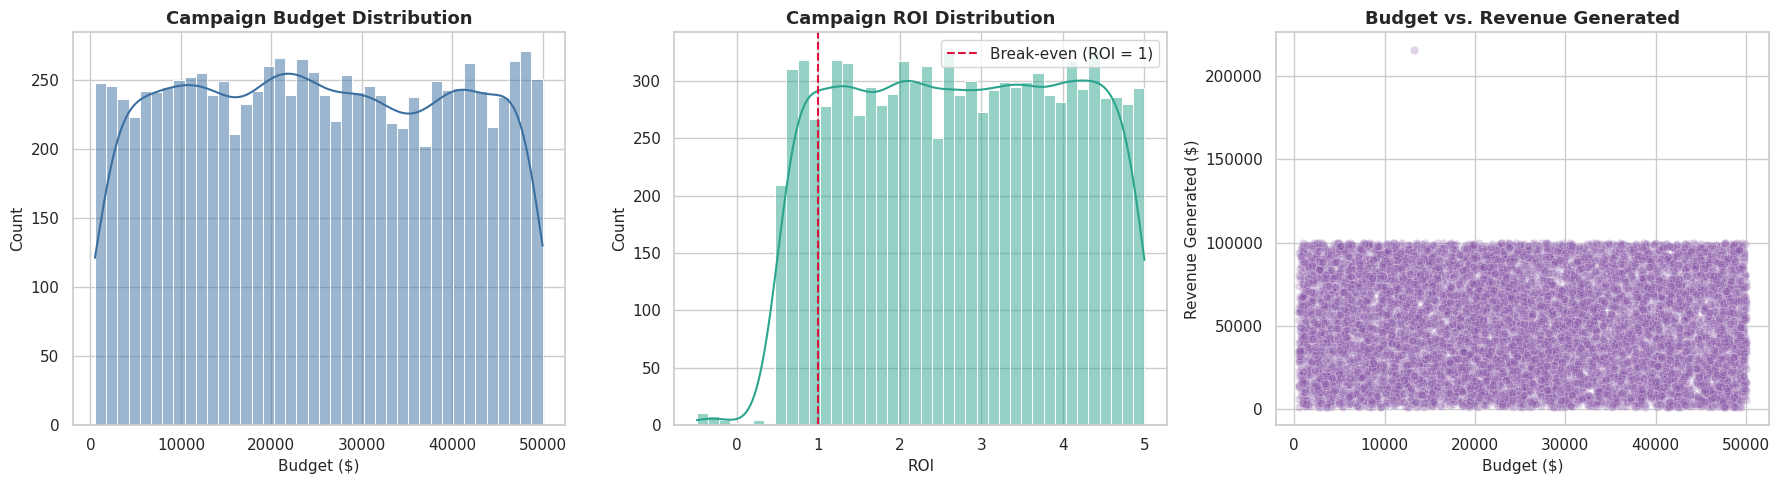

Correlation between Budget and Revenue_Generated: -0.024
Mean ROI: 2.74 | Median ROI: 2.74
Share of campaigns with ROI < 1 (unprofitable): 11.2%
Share of campaigns with ROI < 0 (losing money outright): 0.3%


In [323]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data['Budget'], bins=40, kde=True, ax=axes[0], color='#3b6fa0')
axes[0].set_title('Campaign Budget Distribution')
axes[0].set_xlabel('Budget ($)')

sns.histplot(data['ROI'], bins=40, kde=True, ax=axes[1], color='#2ca58d')
axes[1].axvline(1, color='crimson', linestyle='--', linewidth=1.5, label='Break-even (ROI = 1)')
axes[1].set_title('Campaign ROI Distribution')
axes[1].set_xlabel('ROI')
axes[1].legend()

sns.scatterplot(data=data, x='Budget', y='Revenue_Generated', alpha=0.25, ax=axes[2], color='#8856a7')
axes[2].set_title('Budget vs. Revenue Generated')
axes[2].set_xlabel('Budget ($)')
axes[2].set_ylabel('Revenue Generated ($)')

plt.tight_layout()
plt.show()

corr = data['Budget'].corr(data['Revenue_Generated'])
print(f"Correlation between Budget and Revenue_Generated: {corr:.3f}")
print(f"Mean ROI: {data['ROI'].mean():.2f} | Median ROI: {data['ROI'].median():.2f}")
print(f"Share of campaigns with ROI < 1 (unprofitable): {(data['ROI'] < 1).mean()*100:.1f}%")
print(f"Share of campaigns with ROI < 0 (losing money outright): {(data['ROI'] < 0).mean()*100:.1f}%")


**Business interpretation:** The scatter plot and the near-zero correlation coefficient tell a clear story: **campaign budget size has essentially no relationship with the revenue it generates.** A campaign spending \$5,000 is just as likely to outperform a \$45,000 campaign as the reverse. On top of that, roughly **1 in 10 campaigns runs at an ROI below break-even (< 1)**, meaning the campaign spent more than it returned.

This is a red flag worth investigating operationally: if bigger budgets aren't reliably buying more revenue, the **targeting, creative, or channel mix** — not the budget size — is likely what's actually driving performance. This is exactly the kind of finding covered as a **business problem with a clear recommendation in Section 7**.


### Marketing Efficiency: Cost per Conversion & Conversion Rate


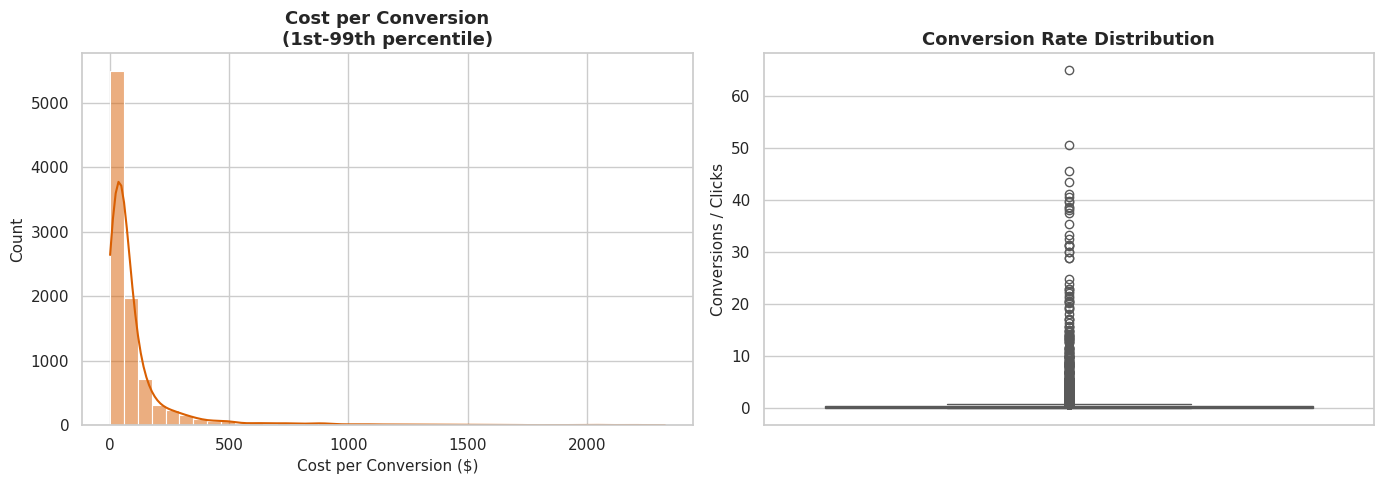

Median Cost per Conversion: $50.38
Median Conversion Rate: 0.20


In [324]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trim to 1st-99th percentile for a readable view of a skewed ratio metric (see Section 5 note)
cpc_trimmed = data['Cost_per_Conversion'][
    data['Cost_per_Conversion'].between(*data['Cost_per_Conversion'].quantile([0.01, 0.99]))
]
sns.histplot(cpc_trimmed, bins=40, kde=True, ax=axes[0], color='#d95f02')
axes[0].set_title('Cost per Conversion\n(1st-99th percentile)')
axes[0].set_xlabel('Cost per Conversion ($)')

sns.boxplot(data=data, y='Conversion_Rate', ax=axes[1], color='#66c2a5')
axes[1].set_title('Conversion Rate Distribution')
axes[1].set_ylabel('Conversions / Clicks')

plt.tight_layout()
plt.show()

print(f"Median Cost per Conversion: ${data['Cost_per_Conversion'].median():,.2f}")
print(f"Median Conversion Rate: {data['Conversion_Rate'].median():.2f}")


**Business interpretation:** The median cost per conversion is a useful efficiency benchmark, but the distribution has a long right tail — a meaningful subset of campaigns pay far more per conversion than the median. Combined with the `Conversions > Clicks` data-integrity issue flagged in Section 4.4, we treat the **conversion rate figures directionally** rather than as a precise attribution metric, and recommend fixing the underlying click/conversion tracking (Section 7) before using this KPI for budget-allocation decisions.


### Flash Sales: Does a Deeper Discount Sell More Units?


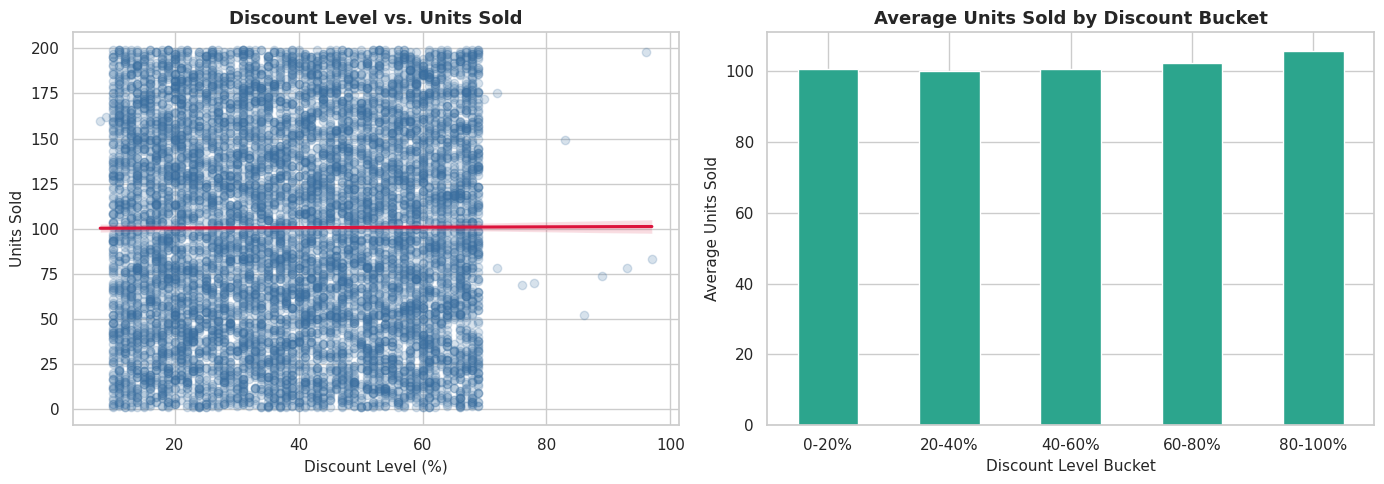

Correlation between Discount_Level and Units_Sold: 0.003
                  mean  count
Discount_Bucket              
0-20%           100.70   1783
20-40%          100.10   3225
40-60%          100.50   3285
60-80%          102.20   1392
80-100%         105.70      6


In [325]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=data, x='Discount_Level', y='Units_Sold', scatter_kws={'alpha':0.2, 'color':'#3b6fa0'},
            line_kws={'color': 'crimson'}, ax=axes[0])
axes[0].set_title('Discount Level vs. Units Sold')
axes[0].set_xlabel('Discount Level (%)')
axes[0].set_ylabel('Units Sold')

data['Discount_Bucket'].value_counts()  # created in Section 5.3
bucket_avg = data.groupby('Discount_Bucket', observed=True)['Units_Sold'].mean()
bucket_avg.plot(kind='bar', ax=axes[1], color='#2ca58d')
axes[1].set_title('Average Units Sold by Discount Bucket')
axes[1].set_xlabel('Discount Level Bucket')
axes[1].set_ylabel('Average Units Sold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

corr = data['Discount_Level'].corr(data['Units_Sold'])
print(f"Correlation between Discount_Level and Units_Sold: {corr:.3f}")
print(data.groupby('Discount_Bucket', observed=True)['Units_Sold'].agg(['mean', 'count']).round(1))


**Business interpretation:** Discount depth shows **essentially no relationship with units sold** — flash sales at a 10% discount move about as many units, on average, as flash sales at 60%+. This is an important, counter-intuitive finding: the data does not support the common assumption that "deeper discount = more volume." If confirmed with cleaner tracking data (see Section 8 limitations), this would suggest **discount depth is eroding margin without a corresponding lift in volume** — a high-priority item in Section 7.

*(Note: the 80-100% bucket contains only a handful of records in this dataset and should not be over-interpreted on its own.)*


### Discount Depth vs. Customer Satisfaction


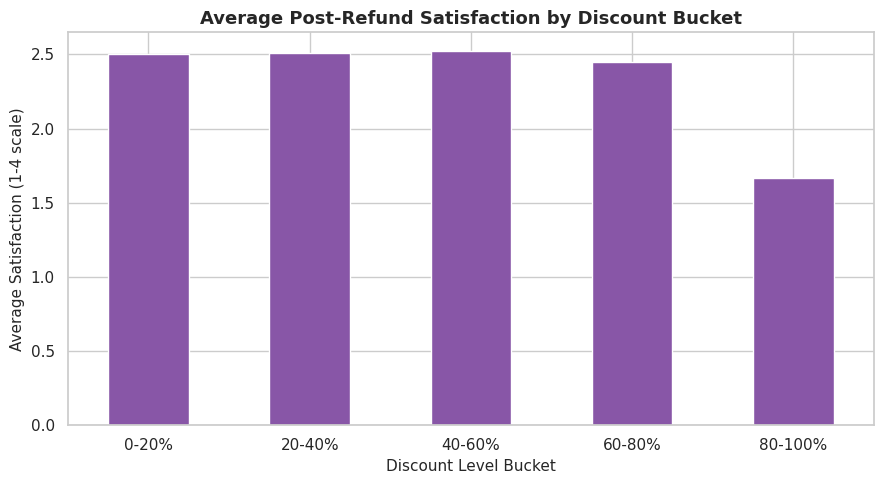

                 mean  count
Discount_Bucket             
0-20%            2.50   1783
20-40%           2.51   3225
40-60%           2.52   3285
60-80%           2.45   1392
80-100%          1.67      6


In [326]:
fig, ax = plt.subplots(figsize=(9, 5))
sat_by_bucket = data.groupby('Discount_Bucket', observed=True)['Customer_Satisfaction_Post_Refund'].mean()
sat_by_bucket.plot(kind='bar', ax=ax, color='#8856a7')
ax.set_title('Average Post-Refund Satisfaction by Discount Bucket')
ax.set_xlabel('Discount Level Bucket')
ax.set_ylabel('Average Satisfaction (1-4 scale)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(data.groupby('Discount_Bucket', observed=True)['Customer_Satisfaction_Post_Refund'].agg(['mean', 'count']).round(2))


**Business interpretation:** Satisfaction scores stay fairly flat (~2.4-2.5 out of 4) across most discount levels, with a lower average only in the very-high-discount bucket — which, again, has too few records here to draw a confident conclusion. The main takeaway is that **satisfaction does not visibly improve with deeper discounts**, reinforcing the Section 6.3 finding that discounting isn't clearly earning the company anything in return (neither more volume nor happier customers) — it's mainly a margin cost.


### Subscription Tier: Revenue, ROI, and Satisfaction


In [327]:
tier_summary = data.groupby('Subscription_Tier', observed=True).agg(
    Avg_Revenue=('Revenue_Generated', 'mean'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Satisfaction=('Customer_Satisfaction_Post_Refund', 'mean'),
    Avg_Cost_per_Conversion=('Cost_per_Conversion', 'median'),
    Customers=('Customer_ID', 'count'),
).round(2)
tier_summary = tier_summary.sort_values('Avg_Revenue', ascending=False)
tier_summary


,Avg_Revenue,Avg_ROI,Avg_Satisfaction,Avg_Cost_per_Conversion,Customers
Subscription_Tier,,,,,
Basic,"50,218.39",2.77,2.50,49.58,3303
Premium,"50,159.78",2.73,2.47,50.20,3197
Standard,"49,768.76",2.72,2.54,51.70,3191


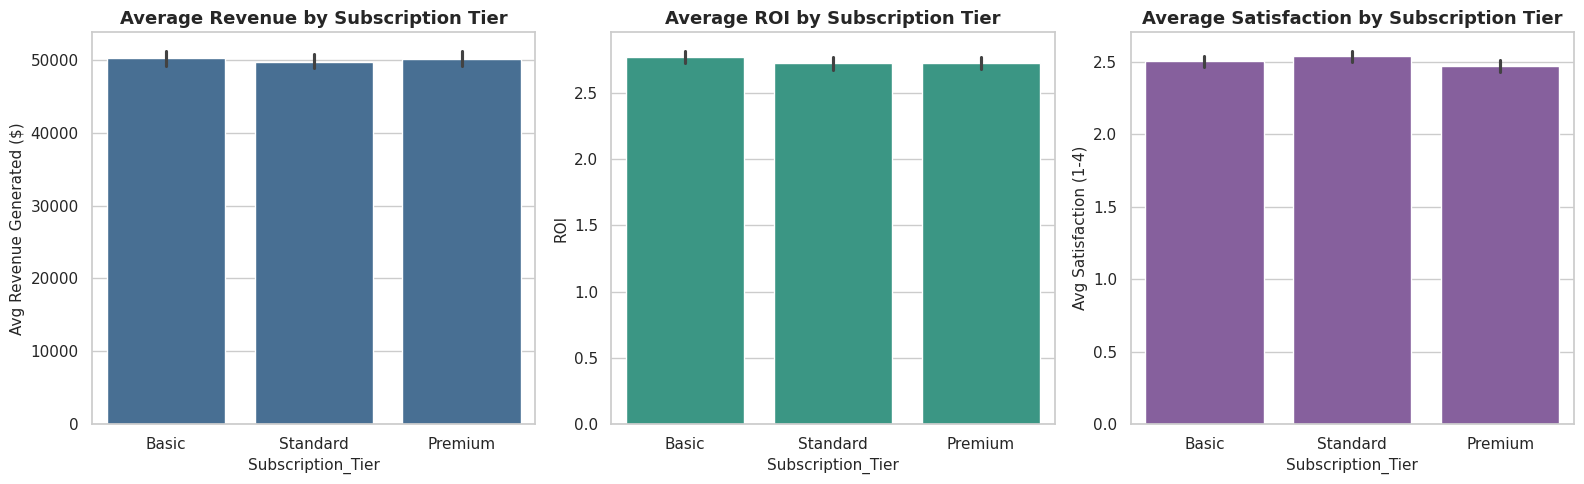

In [328]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=data, x='Subscription_Tier', y='Revenue_Generated', estimator=np.mean,
            errorbar=('ci', 95), ax=axes[0], order=['Basic', 'Standard', 'Premium'], color='#3b6fa0')
axes[0].set_title('Average Revenue by Subscription Tier')
axes[0].set_ylabel('Avg Revenue Generated ($)')

sns.barplot(data=data, x='Subscription_Tier', y='ROI', estimator=np.mean,
            errorbar=('ci', 95), ax=axes[1], order=['Basic', 'Standard', 'Premium'], color='#2ca58d')
axes[1].set_title('Average ROI by Subscription Tier')

sns.barplot(data=data, x='Subscription_Tier', y='Customer_Satisfaction_Post_Refund', estimator=np.mean,
            errorbar=('ci', 95), ax=axes[2], order=['Basic', 'Standard', 'Premium'], color='#8856a7')
axes[2].set_title('Average Satisfaction by Subscription Tier')
axes[2].set_ylabel('Avg Satisfaction (1-4)')

plt.tight_layout()
plt.show()


**Business interpretation:** Revenue, ROI, and satisfaction are **remarkably similar across Basic, Standard, and Premium tiers** — Premium customers are not generating materially more revenue or reporting higher satisfaction than Basic customers in this dataset. If this holds up with better-linked data (see Section 8), it raises a real strategic question: **is the Premium tier priced/positioned in a way that reflects its actual incremental value to the business?** This is explored further in Section 7.


### Marketing Keyword Performance & Bundle Pricing


In [329]:
keyword_summary = data.groupby('Common_Keywords', observed=True).agg(
    Avg_Revenue=('Revenue_Generated', 'mean'),
    Avg_Units_Sold=('Units_Sold', 'mean'),
    Avg_Bundle_Price=('Bundle_Price', 'mean'),
    Avg_Revenue_per_Unit=('Revenue_per_Unit', 'median'),
    Records=('Product_ID', 'count'),
).round(2).sort_values('Avg_Revenue', ascending=False)
keyword_summary


,Avg_Revenue,Avg_Units_Sold,Avg_Bundle_Price,Avg_Revenue_per_Unit,Records
Common_Keywords,,,,,
Affordable,"50,945.86",100.63,278.80,509.72,2478
Innovative,"50,599.33",102.79,276.14,497.81,2414
Durable,"50,328.55",99.34,273.82,508.83,2362
Stylish,"48,328.94",99.83,271.17,486.38,2437


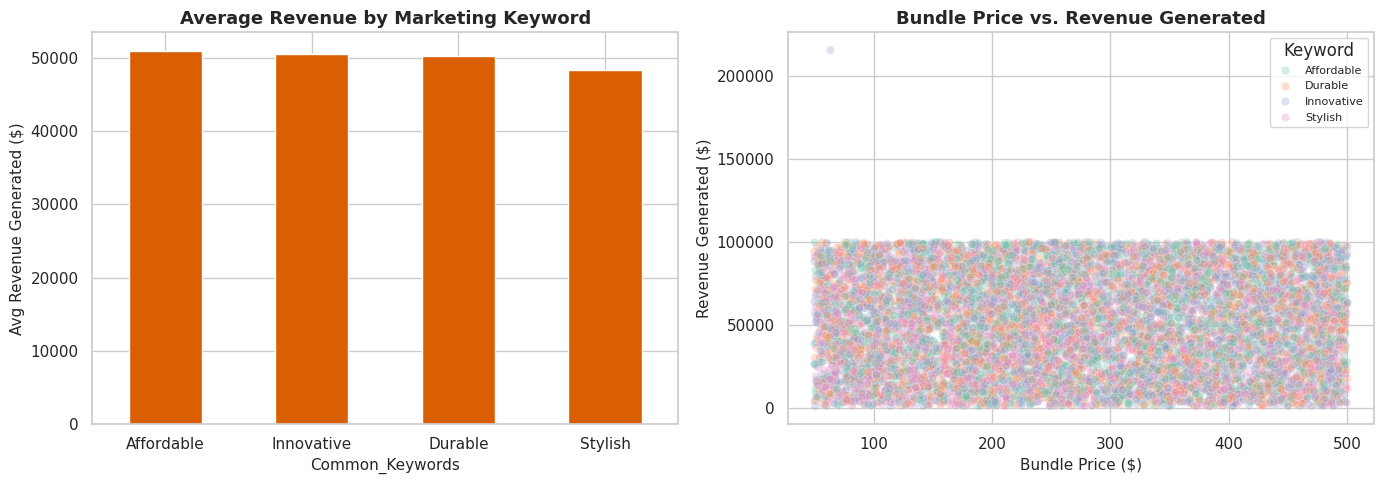

Correlation between Bundle_Price and Revenue_Generated: -0.004


In [330]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

keyword_summary['Avg_Revenue'].plot(kind='bar', ax=axes[0], color='#d95f02')
axes[0].set_title('Average Revenue by Marketing Keyword')
axes[0].set_ylabel('Avg Revenue Generated ($)')
axes[0].tick_params(axis='x', rotation=0)

sns.scatterplot(data=data, x='Bundle_Price', y='Revenue_Generated', hue='Common_Keywords',
                 alpha=0.3, ax=axes[1], palette='Set2')
axes[1].set_title('Bundle Price vs. Revenue Generated')
axes[1].set_xlabel('Bundle Price ($)')
axes[1].set_ylabel('Revenue Generated ($)')
axes[1].legend(title='Keyword', fontsize=8)

plt.tight_layout()
plt.show()

corr = data['Bundle_Price'].corr(data['Revenue_Generated'])
print(f"Correlation between Bundle_Price and Revenue_Generated: {corr:.3f}")


**Business interpretation:** "Affordable" and "Innovative"-tagged products lead narrowly on average revenue, but the differences between all four keywords are small — no single keyword stands out as a dramatically stronger driver of revenue in this dataset. Bundle price itself is **not correlated with revenue generated**, meaning higher-priced bundles are not reliably outselling cheaper ones in revenue terms. This is useful context for Product/Merchandising: **bundle price alone is not a lever for revenue growth** in the current data; other factors (not captured here) are likely driving purchase decisions.


### Correlation Overview

A single correlation heatmap across all numeric business metrics, to sanity-check the pairwise findings above and look for any relationship we might have missed.


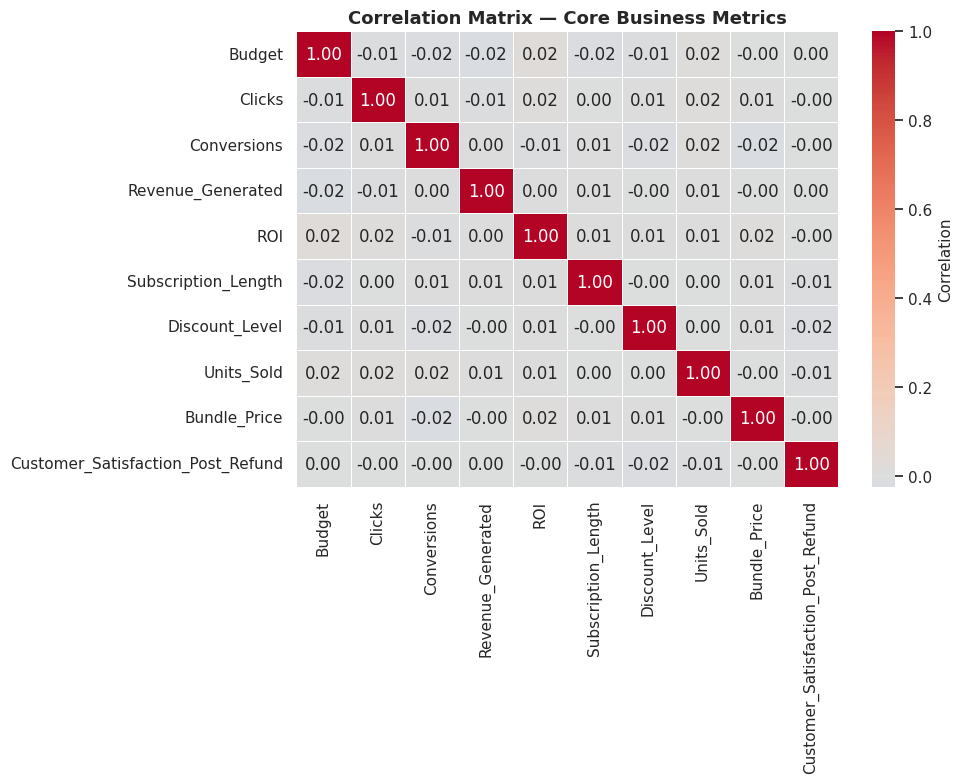

In [331]:
numeric_for_corr = ['Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'ROI',
                     'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price',
                     'Customer_Satisfaction_Post_Refund']

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = data[numeric_for_corr].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix — Core Business Metrics')
plt.tight_layout()
plt.show()


**Business interpretation:** Every pairwise correlation among the core business metrics is close to zero. Taken at face value, this means **none of the numeric levers in this dataset (spend, clicks, discount depth, subscription length, bundle price) are linearly related to revenue, ROI, units sold, or satisfaction.** This is an unusually "flat" correlation structure for a real operational dataset, and we treat it as a genuine finding worth flagging to leadership rather than something to explain away


### Customer Satisfaction Overview


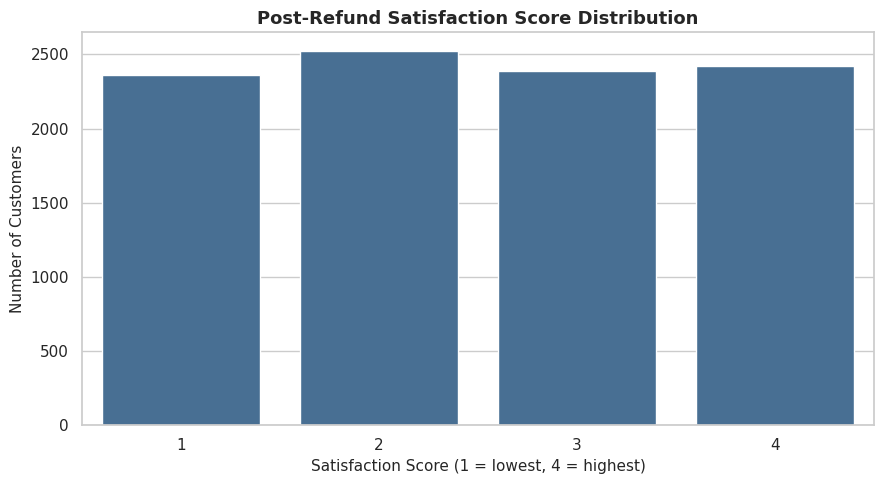

Share of customers by satisfaction score:
Customer_Satisfaction_Post_Refund
1   24.30
2   26.00
3   24.60
4   25.00
Name: proportion, dtype: float64


In [332]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=data, x='Customer_Satisfaction_Post_Refund', ax=ax, color='#3b6fa0')
ax.set_title('Post-Refund Satisfaction Score Distribution')
ax.set_xlabel('Satisfaction Score (1 = lowest, 4 = highest)')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

sat_share = (data['Customer_Satisfaction_Post_Refund'].value_counts(normalize=True) * 100).sort_index()
print("Share of customers by satisfaction score:")
print(sat_share.round(1))


**Business interpretation:** Scores are fairly evenly spread across the 1-4 scale, with a slight lean toward the lower half (1-2). Since this metric is captured specifically **after a refund**, this distribution is a meaningful signal about how well refund/service-recovery moments are being handled — roughly half of post-refund customers rate the experience in the bottom half of the scale, which is an opportunity area addressed in Section 7.


### Putting the Engineered Segments to Work

Section 5 built several business-friendly segments (`ROI_Tier`, `Budget_Tier`, `Subscription_Tenure_Group`, `High_Value_Campaign`). Here we use them directly to answer two practical questions: **"does spending more actually buy a better ROI tier?"** and **"do longer-tenured customers report better satisfaction?"**


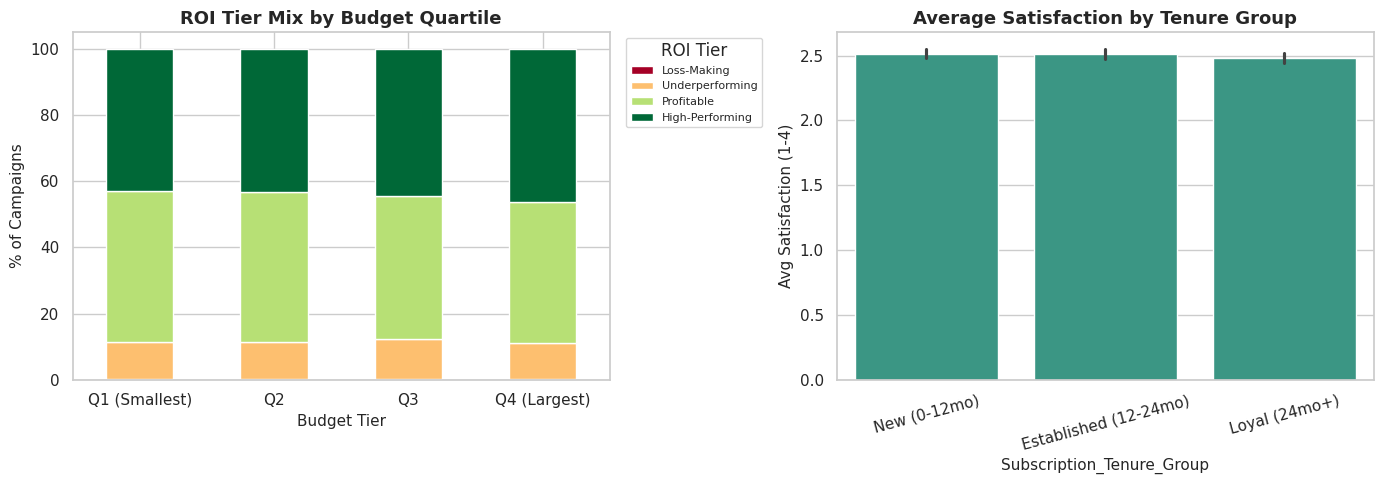

High-value campaigns (top-quartile revenue AND profitable) by Budget Tier:
Budget_Tier
Q1 (Smallest)   23.80
Q2              22.50
Q3              20.60
Q4 (Largest)    22.00
Name: High_Value_Campaign, dtype: float64


In [333]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

roi_tier_by_budget = pd.crosstab(data['Budget_Tier'], data['ROI_Tier'], normalize='index') * 100
roi_tier_by_budget = roi_tier_by_budget[['Loss-Making', 'Underperforming', 'Profitable', 'High-Performing']]
roi_tier_by_budget.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn')
axes[0].set_title('ROI Tier Mix by Budget Quartile')
axes[0].set_ylabel('% of Campaigns')
axes[0].set_xlabel('Budget Tier')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='ROI Tier', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

sns.barplot(data=data, x='Subscription_Tenure_Group', y='Customer_Satisfaction_Post_Refund',
            estimator=np.mean, errorbar=('ci', 95), ax=axes[1],
            order=['New (0-12mo)', 'Established (12-24mo)', 'Loyal (24mo+)'], color='#2ca58d')
axes[1].set_title('Average Satisfaction by Tenure Group')
axes[1].set_ylabel('Avg Satisfaction (1-4)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("High-value campaigns (top-quartile revenue AND profitable) by Budget Tier:")
print(data.groupby('Budget_Tier', observed=True)['High_Value_Campaign'].mean().mul(100).round(1))


**Business interpretation:** The ROI-tier mix is nearly identical across every budget quartile — the smallest-budget campaigns (Q1) are **just as likely** to land in the "High-Performing" ROI tier as the largest-budget campaigns (Q4). This reinforces the Section 6.1 finding with a segment-level view: **bigger budgets are not buying a better outcome tier**, they're simply spreading the same odds of success across more dollars. Similarly, average satisfaction is flat across New, Established, and Loyal customer tenure groups — tenure alone does not predict how a customer will rate a post-refund experience. Both segment-level views support the Priority 1 and Priority 5 recommendations in Section 7.


## Business Problems & Data-Driven Recommendations

Each problem below is grounded in a specific finding from Section 6, ranked by estimated business impact (High / Medium / Low), with a practical recommendation and an explanation of how it addresses the problem.

---

### 🔴 Priority 1 (High Impact): Marketing spend is not reliably driving revenue or ROI

**Evidence:** Budget and Revenue_Generated have a correlation of essentially 0 (Section 6.1); roughly **1 in 10 campaigns has ROI below break-even**, and a small share are actively losing money.

**Recommendation:**
- Move budget-allocation decisions away from "spend more on this campaign" toward a **test-and-learn framework**: run smaller, controlled budget increments per channel/creative and measure marginal ROI before scaling.
- Immediately audit and pause the bottom ROI decile of campaigns; reallocate that spend to the top ROI quartile.
- Fix attribution/tracking (see Priority 3) before drawing further conclusions — a zero correlation can also be a symptom of **broken measurement**, not just genuinely ineffective spend.

**Why this matters most:** Budget is the single largest controllable cost in this dataset; even a modest improvement in spend efficiency has the largest dollar impact of any recommendation here.

---

### 🟠 Priority 2 (High Impact): Discounting is not clearly earning incremental volume or satisfaction

**Evidence:** Discount_Level shows no meaningful relationship with Units_Sold (Section 6.3) or with post-refund satisfaction (Section 6.4).

**Recommendation:**
- Run a **controlled discount-depth A/B test** (e.g., 10% vs. 30% vs. 50% on matched products) to establish a true causal relationship, since the current data is observational and can't prove causation on its own.
- Until that test is run, **cap flash-sale discounts at a moderate default level** (e.g., the 20-40% band, which already covers the majority of volume) rather than defaulting to deep discounts, to protect margin while the hypothesis is tested.

**Why this matters:** Deep discounts directly cut gross margin; if they aren't buying extra volume, this is pure margin leakage that compounds every sale cycle.

---

### 🟡 Priority 3 (Medium-High Impact): Marketing measurement and tracking integrity is broken

**Evidence:** `Conversions` exceeds `Clicks` in ~10% of records (Section 4.4); several other columns showed systematic sign/scale/offset data-entry errors that had to be reverse-engineered in Section 4.

**Recommendation:**
- Audit the campaign-tracking pipeline (ad platform → analytics → data warehouse) for the source of the click/conversion mismatch — likely a **deduplication or session-attribution bug**, or a bug merging data from multiple sources.
- Add automated data-quality checks (range validation, e.g. `Discount_Level` between 0-100, `Conversions <= Clicks`) at the point of ingestion, not after the fact.

**Why this matters:** Every other recommendation in this report depends on the underlying data being trustworthy. Fixing this compounds the value of every future analysis.

---

### 🟢 Priority 4 (Medium Impact): Premium subscribers aren't outperforming lower tiers

**Evidence:** Revenue, ROI, and satisfaction are nearly flat across Basic / Standard / Premium tiers (Section 6.5).

**Recommendation:**
- Review what **incremental benefits** Premium actually delivers versus Basic — if the value proposition isn't translating into measurably better outcomes, either the tier needs stronger differentiated benefits, or its price point should be reassessed.
- Segment Premium customers further (e.g., by tenure, product category) to check whether the "flat" pattern hides a real sub-segment that IS performing better, which a single tier-level average could be masking.

**Why this matters:** Subscription tiers are a recurring revenue lever; if Premium isn't earning its premium, that's a pricing/packaging opportunity.

---

### 🔵 Priority 5 (Medium Impact): Post-refund satisfaction skews low for a meaningful share of customers

**Evidence:** Roughly half of post-refund satisfaction scores fall in the bottom half of the 1-4 scale (Section 6.8).

**Recommendation:**
- Treat the refund moment as a **service-recovery opportunity**: review refund-process turnaround time, communication, and any friction customers report immediately after a refund is processed.
- Set up a **closed-loop follow-up** for customers who score 1-2 post-refund, since these customers are already a churn risk and are already engaged in a support-adjacent workflow.

**Why this matters:** Refund moments are high-risk, high-visibility touchpoints for retention; small experience improvements here are relatively low-cost.

---

### ⚪ Explicitly flagged limitation: Insufficient evidence for causal claims

For every finding above, **this dataset only supports observational, correlational conclusions.** We do not have a time dimension, a control/holdout group, or a customer-level history across campaigns, so we cannot confirm, for example, that discounting *causes* flat volume rather than simply coinciding with it in this sample. Recommendation: **before reallocating significant budget**, validate the highest-impact findings (Priority 1 and 2) with a proper controlled experiment.


In [334]:
data.to_excel('Marketing Performance.xlsx',index=False)